In [80]:
library(tidyverse)
library(dplyr)
library(cowplot)
library("RColorBrewer")
library(ggplot2)
library(BSDA)
library(rstatix)

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

In [81]:
# Read file
fp_tp1 <- read.csv("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/feacal/tp1_nulliparous/2025-08-01fp_tp1_filt_nulliparous.csv", header = TRUE)
sp_tp1 <- read.csv("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/feacal/tp1_nulliparous/2025-08-01sp_tp1_filt_nulliparous.csv", header = TRUE)
combined_fp_sp <- read.csv("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/feacal/tp1_nulliparous/2025-08-01_combined_fp_sp_tp1.csv", header = TRUE)

In [82]:

combined_fp_sp$Group

[1] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
 [5] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
 [9] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
[13] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
[17] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
[21] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
[25] "First pregnancy " "Second pregnancy" "Second pregnancy" "Second pregnancy"
[29] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[33] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[37] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[41] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[45] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[49] "Second pregnancy" "Second pregnancy"

In [83]:
head(fp_tp1)
dim(fp_tp1)

,X,Studienummer,Correct_PN,Prev_RPL,Prev_IUFD,Prev_miscarriage_numb,Q1_Datum,Q1_Personnummer,Avbruten_graviditet,age_checked,⋯,diffdays,missfall.IUFD_week,IUFD,missfall,missfall.IUFD_comments,Gest_w_combined,deliv_start_combined,Type_of_PTB,s_PTB,preeclampsia_epi_analysis
,<int>,<chr>,<lgl>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,⋯,<int>,<lgl>,<lgl>,<lgl>,<lgl>,<int>,<chr>,<chr>,<int>,<int>
1,5367,S194e21b,NA,0,0,0,2018-11-16,P159f9c8,0,36,⋯,0,NA,NA,NA,NA,41,Spontaneous,NA,NA,0
2,5297,S1a267fa,NA,0,0,0,2019-05-23,P1a267fa,0,32,⋯,0,NA,NA,NA,NA,38,Spontaneous,NA,NA,0
3,5208,Sa8397fa,NA,0,0,0,2018-03-14,P1ef420d,0,27,⋯,0,NA,NA,NA,NA,28,Spontaneous,very_w28_31,1,0
4,5301,S1f862a6,NA,0,0,0,2018-03-07,P1f862a6,0,32,⋯,0,NA,NA,NA,NA,31,Spontaneous,very_w28_31,1,0
5,5285,S3c0f6ee,NA,0,0,0,2019-03-25,P3c0f6ee,0,31,⋯,0,NA,NA,NA,NA,38,Spontaneous,NA,NA,0
6,5275,S2b86cc0,NA,0,0,0,2019-05-29,P3cac7b0,0,31,⋯,0,NA,NA,NA,NA,39,Spontaneous,NA,NA,0


[1]  25 566

In [84]:
head(sp_tp1)
dim(sp_tp1)

,X,Studienummer,Correct_PN,Prev_RPL,Prev_IUFD,Prev_miscarriage_numb,Q1_Datum,Q1_Personnummer,Avbruten_graviditet,age_checked,⋯,diffdays,missfall.IUFD_week,IUFD,missfall,missfall.IUFD_comments,Gest_w_combined,deliv_start_combined,Type_of_PTB,s_PTB,preeclampsia_epi_analysis
,<int>,<chr>,<lgl>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,⋯,<int>,<lgl>,<lgl>,<lgl>,<lgl>,<int>,<chr>,<lgl>,<lgl>,<int>
1,5391,S159f9c8,NA,0,0,0,2021-01-28,P159f9c8,0,38,⋯,0,NA,NA,NA,NA,40,Spontaneous,NA,NA,0
2,5332,Sb124b17,NA,0,0,2,2021-01-06,P1a267fa,0,34,⋯,0,NA,NA,NA,NA,41,Spontaneous,NA,NA,0
3,5247,S1ef420d,NA,0,0,1,2020-09-17,P1ef420d,0,30,⋯,0,NA,NA,NA,NA,40,Spontaneous,NA,NA,0
4,5305,Sa79a719,NA,0,0,1,2019-01-17,P1f862a6,0,32,⋯,0,NA,NA,NA,NA,41,Induction,NA,NA,0
5,5310,S5097402,NA,0,0,1,2020-10-18,P3c0f6ee,0,33,⋯,0,NA,NA,NA,NA,39,Spontaneous,NA,NA,0
6,5311,S3cac7b0,NA,0,0,0,2020-10-20,P3cac7b0,0,33,⋯,0,NA,NA,NA,NA,40,Spontaneous,NA,NA,0


[1]  25 566

In [85]:
head(combined_fp_sp)
dim(combined_fp_sp)

,X,Studienummer,Correct_PN,Prev_RPL,Prev_IUFD,Prev_miscarriage_numb,Q1_Datum,Q1_Personnummer,Avbruten_graviditet,age_checked,⋯,missfall.IUFD_week,IUFD,missfall,missfall.IUFD_comments,Gest_w_combined,deliv_start_combined,Type_of_PTB,s_PTB,preeclampsia_epi_analysis,Group
,<int>,<chr>,<lgl>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,⋯,<lgl>,<lgl>,<lgl>,<lgl>,<int>,<chr>,<chr>,<int>,<int>,<chr>
1,5367,S194e21b,NA,0,0,0,2018-11-16,P159f9c8,0,36,⋯,NA,NA,NA,NA,41,Spontaneous,NA,NA,0,First pregnancy
2,5297,S1a267fa,NA,0,0,0,2019-05-23,P1a267fa,0,32,⋯,NA,NA,NA,NA,38,Spontaneous,NA,NA,0,First pregnancy
3,5208,Sa8397fa,NA,0,0,0,2018-03-14,P1ef420d,0,27,⋯,NA,NA,NA,NA,28,Spontaneous,very_w28_31,1,0,First pregnancy
4,5301,S1f862a6,NA,0,0,0,2018-03-07,P1f862a6,0,32,⋯,NA,NA,NA,NA,31,Spontaneous,very_w28_31,1,0,First pregnancy
5,5285,S3c0f6ee,NA,0,0,0,2019-03-25,P3c0f6ee,0,31,⋯,NA,NA,NA,NA,38,Spontaneous,NA,NA,0,First pregnancy
6,5275,S2b86cc0,NA,0,0,0,2019-05-29,P3cac7b0,0,31,⋯,NA,NA,NA,NA,39,Spontaneous,NA,NA,0,First pregnancy


[1]  50 567

# ===============================================================================

# Quantitative =========================================================================================================

## Continuous ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

### Age -----------------------------------------------------------------------------------------------------------------------

In [86]:
dye <- c("First pregnancy " = "darkgoldenrod3", "Second pregnancy" = "turquoise4")
combined_fp_sp$Group

[1] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
 [5] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
 [9] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
[13] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
[17] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
[21] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
[25] "First pregnancy " "Second pregnancy" "Second pregnancy" "Second pregnancy"
[29] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[33] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[37] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[41] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[45] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[49] "Second pregnancy" "Second pregnancy"

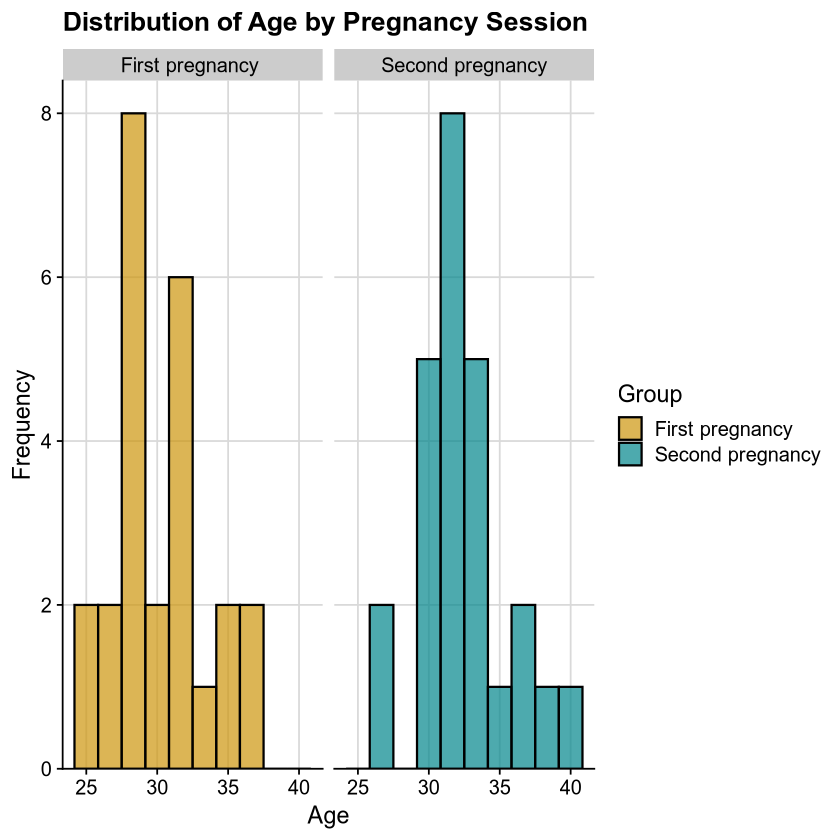

In [87]:
# Histogram of age distribution, grouped by pregnancy session (First vs Second)
age_histogram_combined <- combined_fp_sp |>
  ggplot(aes(x = age_checked, fill = Group)) +
  geom_histogram(bins = 10, col="black", alpha = 0.7, na.rm = TRUE)+
  facet_wrap(~ Group) + # Create one histogram per group 
  labs(
    x = "Age",
    y ="Frequency",
    title ="Distribution of Age by Pregnancy Session"
  ) +
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +    
    scale_fill_manual(values = dye) 
age_histogram_combined + theme_half_open() +
  background_grid()

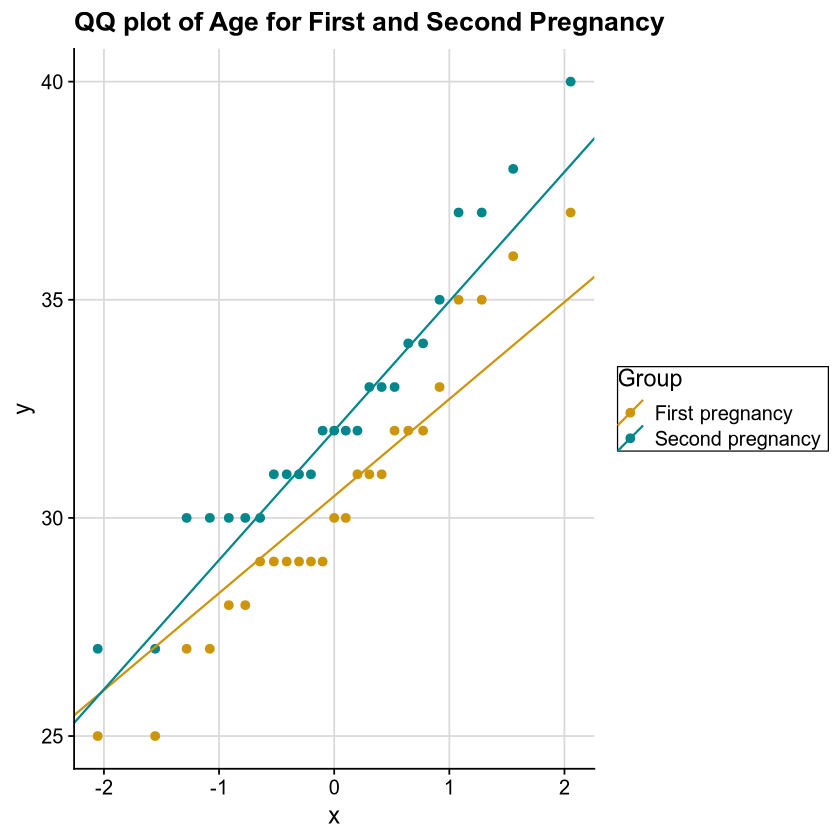

In [88]:
# QQ plot
age_qq_plot <- combined_fp_sp |>
  ggplot(aes(sample = age_checked, color = Group))+
  stat_qq() + 
  stat_qq_line() +
  labs(
    title = "QQ plot of Age for First and Second Pregnancy"
  ) +
  scale_colour_manual(values = dye)  +
  theme_half_open() +
  background_grid() +
  theme(
    legend.box.background = element_rect(color = "black")
  )
age_qq_plot
#display.brewer.all()

In [89]:
# Shapiro test
# In agreement with histogram --> normaly distributed
shapiro_first <- shapiro.test(fp_tp1$age_checked)
shapiro_first


	Shapiro-Wilk normality test

data:  fp_tp1$age_checked
W = 0.95834, p-value = 0.3824


In [90]:
shapiro_second <- shapiro.test(sp_tp1$age_checked)
shapiro_second


	Shapiro-Wilk normality test

data:  sp_tp1$age_checked
W = 0.9413, p-value = 0.1586


In [91]:
R.Version()

$platform
[1] "x86_64-conda-linux-gnu"

$arch
[1] "x86_64"

$os
[1] "linux-gnu"

$system
[1] "x86_64, linux-gnu"

$status
[1] ""

$major
[1] "4"

$minor
[1] "4.3"

$year
[1] "2025"

$month
[1] "02"

$day
[1] "28"

$`svn rev`
[1] "87843"

$language
[1] "R"

$version.string
[1] "R version 4.4.3 (2025-02-28)"

$nickname
[1] "Trophy Case"

In [92]:
combined_fp_sp_sorted <- combined_fp_sp[ order(combined_fp_sp$Q1_Personnummer, combined_fp_sp$Group), ]

fp_data <- combined_fp_sp_sorted$age_checked[combined_fp_sp_sorted$Group == "First pregnancy "]
sp_data <- combined_fp_sp_sorted$age_checked[combined_fp_sp_sorted$Group == "Second pregnancy"]
t.test(fp_data, sp_data, paired = TRUE)


	Paired t-test

data:  fp_data and sp_data
t = -16.694, df = 24, p-value = 1.034e-14
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -2.292213 -1.787787
sample estimates:
mean difference 
          -2.04 


### BMI --------------------------------------------------------------------------------------------------------------------------------------------------------------

In [93]:
# BMI (numerical)
combined_fp_sp$BMI_prior

[1] 21 21 25 25 36 21 21 24 23 28 19 21 20 16 27 29 22 23 23 24 23 29 19 23 23
[26] 25 22 27 25 37 22 23 23 24 29 19 20 21 17 26 29 24 28 23 26 23 30 19 23 21

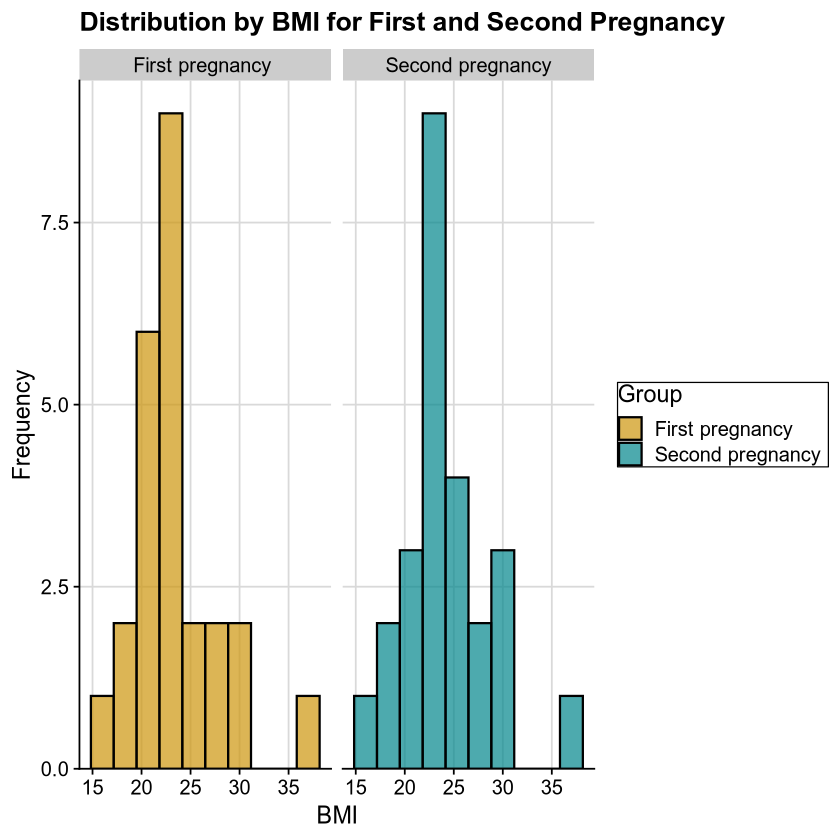

In [94]:
bmi_histogram_combined <- combined_fp_sp |>
  ggplot(aes(x = BMI_prior, fill =Group)) +
  geom_histogram(bins = 10, col = "black", alpha = 0.7, na.rm = TRUE) +
  facet_wrap(~ Group) +
  labs(
    x = "BMI",
    y = "Frequency",
    title = "Distribution by BMI for First and Second Pregnancy"
  ) +
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +
    scale_fill_manual(values = dye) +
  theme_half_open() +
  background_grid() +
  theme(
    legend.box.background = element_rect(color = "black")
  )
bmi_histogram_combined

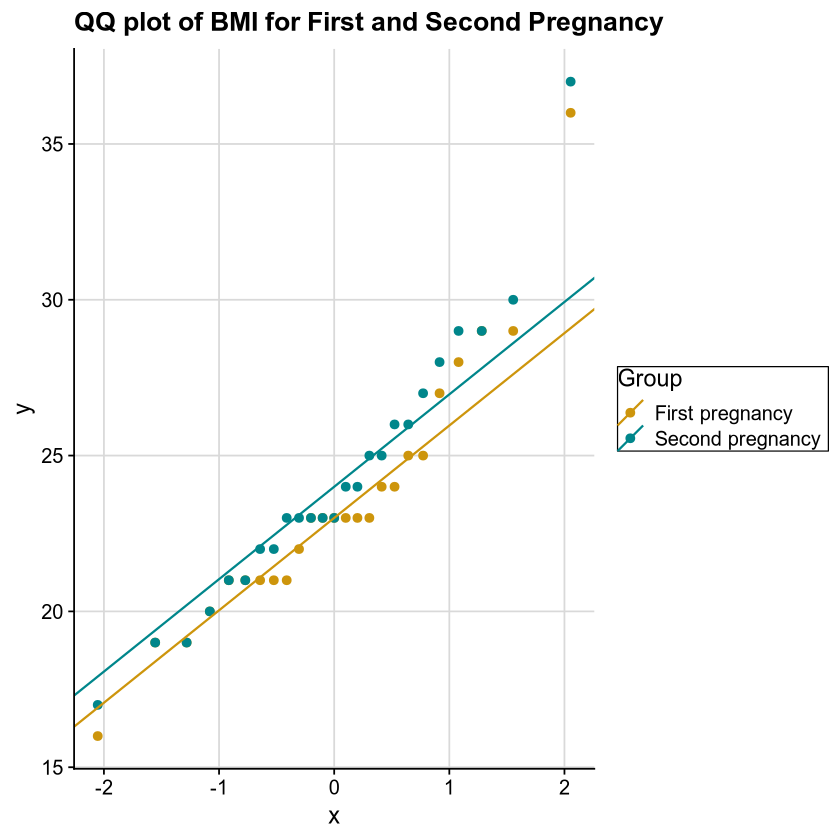

In [95]:
# bmi QQ plot
bmi_qq_plot <- combined_fp_sp |>
  ggplot(aes(sample = BMI_prior, color = Group)) +
  stat_qq() + 
  stat_qq_line() +
  labs (
    title = "QQ plot of BMI for First and Second Pregnancy"
  ) +
  scale_colour_manual(values = dye) +
  theme_half_open() +
  background_grid() +
  theme(
    legend.box.background = element_rect(color = "black")
  )
bmi_qq_plot
  

In [96]:
# Shapiro test
shapiro_first_bmi <- shapiro.test(fp_tp1$BMI_prior)
shapiro_first_bmi


	Shapiro-Wilk normality test

data:  fp_tp1$BMI_prior
W = 0.91231, p-value = 0.03433


In [97]:
shapiro_second_bmi <- shapiro.test(sp_tp1$BMI_prior)
shapiro_second_bmi


	Shapiro-Wilk normality test

data:  sp_tp1$BMI_prior
W = 0.9408, p-value = 0.1545


In [98]:
# Since parametric --> t-test
combined_fp_sp_sorted <- combined_fp_sp[ order(combined_fp_sp$Q1_Personnummer, combined_fp_sp$Group), ]

fp_data_bmi <- combined_fp_sp_sorted$BMI_prior[combined_fp_sp_sorted$Group == "First pregnancy "]
sp_data_bmi <- combined_fp_sp_sorted$BMI_prior[combined_fp_sp_sorted$Group == "Second pregnancy"]
t.test(fp_data_bmi, sp_data_bmi, paired = TRUE)


	Paired t-test

data:  fp_data_bmi and sp_data_bmi
t = -2.6186, df = 24, p-value = 0.01506
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -1.4305314 -0.1694686
sample estimates:
mean difference 
           -0.8 


In [99]:
# Since parametric --> t-test
combined_fp_sp_sorted <- combined_fp_sp[ order(combined_fp_sp$Q1_Personnummer, combined_fp_sp$Group), ]

fp_data_bmi <- combined_fp_sp_sorted$BMI_prior[combined_fp_sp_sorted$Group == "First pregnancy "]
sp_data_bmi <- combined_fp_sp_sorted$BMI_prior[combined_fp_sp_sorted$Group == "Second pregnancy"]
t.test(fp_data_bmi, sp_data_bmi, paired = TRUE)


	Paired t-test

data:  fp_data_bmi and sp_data_bmi
t = -2.6186, df = 24, p-value = 0.01506
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -1.4305314 -0.1694686
sample estimates:
mean difference 
           -0.8 


# Categorical ===============================================================================

## Nominal data ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

### Excess weight ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [100]:
class(fp_tp1$excess_weight)
class(sp_tp1$excess_weight)

[1] "character"

[1] "character"

In [101]:
# Convert to factor
fp_tp1 <- fp_tp1 |>
  mutate(excess_weight = as.factor(ifelse(fp_tp1$Q1_X31_Diagnosed_PCOS == "NA", NA, ifelse(excess_weight =="No", 0, 1)))) 
sp_tp1 <- sp_tp1 |>
  mutate(excess_weight = as.factor(ifelse(sp_tp1$Q1_X31_Diagnosed_PCOS == "NA", NA, ifelse(excess_weight =="No", 0, 1)))) 

In [102]:
# Select variables of interest
fp_excess_weight <- fp_tp1 |>
  select(Q1_Personnummer, excess_weight)
sp_excess_weight <- sp_tp1 |>
  select(Q1_Personnummer, excess_weight)

In [103]:
combined_df_excess_weight <-  merge(fp_excess_weight, sp_excess_weight, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))
dim(combined_df_excess_weight)

[1] 25  3

In [104]:
# Contingency table
tab_excess_weight <- table(combined_df_excess_weight$excess_weight_FP, combined_df_excess_weight$excess_weight_SP)
tab_excess_weight

   
    0 1
  0 8 8
  1 1 6

In [105]:
# Non-parametric paired categorical data --> use McNemar's test
mcnemar.test(tab_excess_weight)


	McNemar's Chi-squared test with continuity correction

data:  tab_excess_weight
McNemar's chi-squared = 4, df = 1, p-value = 0.0455


### Gestational Diabetes --------------------------------------------------------------------------------------------------------------------------------------------------------------

In [106]:
class(fp_tp1$Q1_X73.1_Pregnancy_problems_gestational_diabetes)
class(sp_tp1$Q1_X73.1_Pregnancy_problems_gestational_diabetes)

[1] "character"

[1] "character"

In [107]:
combined_fp_sp$Q1_X73.1_Pregnancy_problems_gestational_diabetes

[1] "Nej" NA    NA    NA    "Nej" "Nej" NA    NA    NA    NA    NA    NA   
[13] NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    "Nej" NA   
[25] NA    NA    NA    NA    NA    "Nej" "Nej" NA    NA    NA    NA    NA   
[37] NA    NA    "Nej" NA    NA    NA    NA    NA    NA    NA    "Nej" NA   
[49] NA    NA

In [108]:
fp_tp1 <- fp_tp1 |>
  mutate(Q1_X73.1_Pregnancy_problems_gestational_diabetes = as.factor(ifelse(fp_tp1$Q1_X73.1_Pregnancy_problems_gestational_diabetes == "Nej", 0, 1)))
sp_tp1 <- sp_tp1 |>
  mutate(Q1_X73.1_Pregnancy_problems_gestational_diabetes = as.factor(ifelse(sp_tp1$Q1_X73.1_Pregnancy_problems_gestational_diabetes == "Nej", 0, 1)))

In [109]:
fp_tp1$Q1_X73.1_Pregnancy_problems_gestational_diabetes
sp_tp1$Q1_X73.1_Pregnancy_problems_gestational_diabetes

[1] 0    <NA> <NA> <NA> 0    0    <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA>
[16] <NA> <NA> <NA> <NA> <NA> <NA> <NA> 0    <NA> <NA>
Levels: 0

[1] <NA> <NA> <NA> <NA> 0    0    <NA> <NA> <NA> <NA> <NA> <NA> <NA> 0    <NA>
[16] <NA> <NA> <NA> <NA> <NA> <NA> 0    <NA> <NA> <NA>
Levels: 0

In [110]:
fp_diabetes <- fp_tp1 |>
  select(Q1_Personnummer, Q1_X73.1_Pregnancy_problems_gestational_diabetes)
sp_diabetes <- sp_tp1 |>
  select(Q1_Personnummer, Q1_X73.1_Pregnancy_problems_gestational_diabetes)

In [111]:
combined_df_diabetes <- merge(fp_diabetes, sp_diabetes, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))
head(combined_df_diabetes)
dim(combined_df_diabetes)

,Q1_Personnummer,Q1_X73.1_Pregnancy_problems_gestational_diabetes_FP,Q1_X73.1_Pregnancy_problems_gestational_diabetes_SP
,<chr>,<fct>,<fct>
1,P159f9c8,0,NA
2,P1a267fa,NA,NA
3,P1ef420d,NA,NA
4,P1f862a6,NA,NA
5,P3c0f6ee,0,0
6,P3cac7b0,0,0


[1] 25  3

In [112]:
tab_diabetes <- table(
  factor(combined_df_diabetes$Q1_X73.1_Pregnancy_problems_gestational_diabetes_FP, levels = c(0, 1)),
  factor(combined_df_diabetes$Q1_X73.1_Pregnancy_problems_gestational_diabetes_SP, levels = c(0, 1))
)

In [113]:
tab_diabetes 
mcnemar.test(tab_diabetes)

   
    0 1
  0 2 0
  1 0 0


	McNemar's Chi-squared test

data:  tab_diabetes
McNemar's chi-squared = NaN, df = 1, p-value = NA


### Depression--------------------------------------------------------------------------------------------------------------------------------------------------------------

In [114]:
class(combined_fp_sp$Depression_score_sum_Q1)

[1] "integer"

In [115]:
# Convert to categories
depression_category_fp <- ifelse(fp_tp1$Depression_score_sum_Q1 >= 0 & fp_tp1$Depression_score_sum_Q1 < 13, 0, 
                                 ifelse(fp_tp1$Depression_score_sum_Q1 >= 13 & fp_tp1$Depression_score_sum_Q1 <= 30, 1, NA))
depression_category_fp

depression_category_sp <- ifelse(sp_tp1$Depression_score_sum_Q1 >= 0 & sp_tp1$Depression_score_sum_Q1 < 13,  0, 
                                 ifelse(sp_tp1$Depression_score_sum_Q1 >= 13 & sp_tp1$Depression_score_sum_Q1 <= 30, 1, NA))
depression_category_sp

[1]  0 NA  0  0 NA NA  0  0  0  0  0  0  0  0  1  0  0  0 NA  0  0  0  0  0  0

[1]  0  0 NA  0  0  1  1  0  0  0  0 NA  0  0  0  1  0  1  0  1  0  0  0  0  0

In [116]:
# Add depression category column
fp_tp1$Q1_Depression_category <- as.factor(depression_category_fp)
sp_tp1$Q1_Depression_category <- as.factor(depression_category_sp)
class(fp_tp1$Q1_Depression_category)

[1] "factor"

In [117]:
fp_depression <- fp_tp1 |>
  select(Q1_Personnummer, Q1_Depression_category)
sp_depression <- sp_tp1 |>
  select(Q1_Personnummer, Q1_Depression_category)

In [118]:
combined_df_depression <- merge(fp_depression, sp_depression, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))
combined_df_depression |> head()
dim(combined_df_depression)

,Q1_Personnummer,Q1_Depression_category_FP,Q1_Depression_category_SP
,<chr>,<fct>,<fct>
1,P159f9c8,0,0
2,P1a267fa,NA,0
3,P1ef420d,0,NA
4,P1f862a6,0,0
5,P3c0f6ee,NA,0
6,P3cac7b0,NA,1


[1] 25  3

In [119]:
tab_depression <- table(combined_df_depression$Q1_Depression_category_FP, combined_df_depression$Q1_Depression_category_SP)
tab_depression

   
     0  1
  0 14  4
  1  1  0

In [120]:
mcnemar.test(tab_depression)


	McNemar's Chi-squared test with continuity correction

data:  tab_depression
McNemar's chi-squared = 0.8, df = 1, p-value = 0.3711


In [121]:
# Trying method d

In [122]:
# Select variables of interest
fp_depression <- fp_tp1 |>
  select(Q1_Personnummer, Q1_Depression_category)
fp_depression |> head()

sp_depression <- sp_tp1 |>
  select(Q1_Personnummer, Q1_Depression_category)
sp_depression |> head()

,Q1_Personnummer,Q1_Depression_category
,<chr>,<fct>
1,P159f9c8,0
2,P1a267fa,NA
3,P1ef420d,0
4,P1f862a6,0
5,P3c0f6ee,NA
6,P3cac7b0,NA


,Q1_Personnummer,Q1_Depression_category
,<chr>,<fct>
1,P159f9c8,0
2,P1a267fa,0
3,P1ef420d,NA
4,P1f862a6,0
5,P3c0f6ee,0
6,P3cac7b0,1


In [123]:
# Combine both df so each personal# has two values
combined_df_depression <- merge(fp_depression, sp_depression, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))
combined_df_depression |> head()

,Q1_Personnummer,Q1_Depression_category_FP,Q1_Depression_category_SP
,<chr>,<fct>,<fct>
1,P159f9c8,0,0
2,P1a267fa,NA,0
3,P1ef420d,0,NA
4,P1f862a6,0,0
5,P3c0f6ee,NA,0
6,P3cac7b0,NA,1


In [124]:
# NA ONLY for fp
missing_pn_depression_fp <- combined_df_depression|> filter(is.na(combined_df_depression$Q1_Depression_category_FP) & !is.na(combined_df_depression$Q1_Depression_category_SP)) |> 
  pull(Q1_Personnummer)
missing_pn_depression_fp

[1] "P1a267fa" "P3c0f6ee" "P3cac7b0" "Pa8f3b51"

In [125]:
# NA ONLY for sp
missing_pn_depression_sp <- combined_df_depression |> 
    filter(is.na(combined_df_depression$Q1_Depression_category_SP) & !is.na(combined_df_depression$Q1_Depression_category_FP)) |> 
  pull(Q1_Personnummer)
missing_pn_depression_sp

[1] "P1ef420d" "P5b98b6c"

In [150]:
# Pull personal# where NA for BOTH fp AND sp
missing_pn_depression_both  <- combined_df_depression |> 
    filter(is.na(combined_df_depression$Q1_Depression_category_FP) & is.na(combined_df_depression$Q1_Depression_category_SP)) |> 
  pull(Q1_Personnummer)
missing_pn_depression_both
length(missing_pn_depression_both) # no pn are missing for both

character(0)

[1] 0

In [131]:
# P-value
# Make sure stress_FP and stress_SP are numeric (NOT factors)
combined_df_depression$Q1_Depression_category_FP <- as.numeric(as.character(combined_df_depression$Q1_Depression_category_FP))
combined_df_depression$Q1_Depression_category_SP <- as.numeric(as.character(combined_df_depression$Q1_Depression_category_SP))

In [157]:
# 2. Split into groups
m2 <- combined_df_depression[!is.na(combined_df_depression$Q1_Depression_category_SP) & !is.na(combined_df_depression$Q1_Depression_category_FP), ] # complete
m1 <- combined_df_depression[!is.na(combined_df_depression$Q1_Depression_category_FP) & is.na(combined_df_depression$Q1_Depression_category_SP), ]  # only FP 
m3 <- combined_df_depression[is.na(combined_df_depression$Q1_Depression_category_FP) & !is.na(combined_df_depression$Q1_Depression_category_SP), ]  # only SP

In [158]:
m2 |> dim()
m1 |> dim() # NA for sp
m3 |> dim() # NA for fp

[1] 19  3

[1] 2 3

[1] 4 3

In [159]:
# 3. Sizes
n_total <- nrow(combined_df_depression)
m1_n <- nrow(m1)
m2_n <- nrow(m2)
m3_n <- nrow(m3)

Pms <- m1_n / n_total # missing depression SP
Pmt <- m3_n / n_total # missing depression SP
Pms

[1] 0.08

In [160]:
# 4. Paired estimator Δ̂(P)
delta_paired <- mean(m2$Q1_Depression_category_SP - m2$Q1_Depression_category_FP, na.rm = TRUE)
delta_paired

[1] 0.1578947

In [170]:
# 5. Unpaired estimator Δ̂(U)
P_s <- mean(m1$Q1_Depression_category_FP, na.rm = TRUE) # from m1
P_t <- mean(m3$Q1_Depression_category_SP, na.rm = TRUE) # from m3
delta_unpaired <- P_t - P_s
delta_unpaired

[1] 0.25

In [171]:
P_t
P_s

[1] 0.25

[1] 0

In [163]:
# 6. Calculate components for V_P
P01 <- sum(m2$Q1_Depression_category_FP == 0 & m2$Q1_Depression_category_SP == 1) / m2_n
P10 <- sum(m2$Q1_Depression_category_FP == 1 & m2$Q1_Depression_category_SP == 0) / m2_n
P01
P10


VP <- (P01 + P10 - (P01 - P10)^2) / (1 - Pms - Pmt)
VP

[1] 0.2105263

[1] 0.05263158

[1] 0.3134568

In [164]:
# 7. Calculate VU
VU <- (P_s * (1 - P_s)) / Pms + (P_t * (1 - P_t)) / Pmt
VU

[1] 1.171875

In [165]:
# 8. Weight w and hybrid estimator
w <- VU / (VU + VP)
delta_D <- w * delta_unpaired + (1 - w) * delta_paired

In [166]:
# 9. Combined variance and SE
var_D <- (VU * VP) / (VU + VP)
se_D <- sqrt(var_D)

In [167]:
# 10. Z-test
z_value <- delta_D / se_D
p_value <- 2 * (1 - pnorm(abs(z_value)))
print(p_value)

[1] 0.6429132


### Stress--------------------------------------------------------------------------------------------------------------------------------------------------------------

In [30]:
class(combined_fp_sp$high_stress_Q1)

[1] "integer"

In [31]:
fp_tp1$high_stress_Q1 <- as.factor(fp_tp1$high_stress_Q1 )
sp_tp1$high_stress_Q1 <- as.factor(sp_tp1$high_stress_Q1 )
class(fp_tp1$high_stress_Q1)
class(sp_tp1$high_stress_Q1)

[1] "factor"

[1] "factor"

In [32]:
fp_stress <- fp_tp1 |>
  select(Q1_Personnummer, high_stress_Q1)
sp_stress <- sp_tp1 |>
  select(Q1_Personnummer, high_stress_Q1)
sp_stress

Q1_Personnummer,high_stress_Q1
<chr>,<fct>
P159f9c8,1
P1a267fa,0
P1ef420d,1
P1f862a6,0
P3c0f6ee,0
P3cac7b0,1
P3db7da6,1
P424fd61,0
P4a05456,1


In [33]:
combined_df_stress <- merge(fp_stress, sp_stress, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))
combined_df_stress

Q1_Personnummer,high_stress_Q1_FP,high_stress_Q1_SP
<chr>,<fct>,<fct>
P159f9c8,0,1
P1a267fa,0,0
P1ef420d,0,1
P1f862a6,0,0
P3c0f6ee,1,0
P3cac7b0,1,1
P3db7da6,0,1
P424fd61,0,0
P4a05456,0,1


In [34]:
tab_stress <- table(combined_df_stress$high_stress_Q1_FP, combined_df_stress$high_stress_Q1_SP)

In [35]:
mcnemar.test(tab_stress)


	McNemar's Chi-squared test with continuity correction

data:  tab_stress
McNemar's chi-squared = 2.0833, df = 1, p-value = 0.1489


### Smoking --------------------------------------------------------------------------------------------------------------------------------------------------------------

In [36]:
# Convert Q1_Smoking_ to categories checked
smoking_category_fp <- ifelse(fp_tp1$Q1_Smoking_checked == "Nej, jag har aldrig rökt", 0, 
                           ifelse(fp_tp1$Q1_Smoking_checked == "Rökt tidigare", 0,
                                  ifelse(fp_tp1$Q1_Smoking_checked == "Feströkare", 1, NA)))
table(smoking_category_fp)

smoking_category_fp
 0  1 
24  1 

In [37]:
smoking_category_sp <- ifelse(sp_tp1$Q1_Smoking_checked == "Nej, jag har aldrig rökt", 0, 
                              ifelse(sp_tp1$Q1_Smoking_checked == "Rökt tidigare", 0,
                                     ifelse(sp_tp1$Q1_Smoking_checked == "Feströkare", 1, NA)))
table(smoking_category_sp)

smoking_category_sp
 0 
25 

In [38]:
# Check for NA
sum(is.na(smoking_category_fp))
sum(is.na(smoking_category_sp))

[1] 0

[1] 0

In [39]:
# Create new column with smoking category
fp_tp1$smoking_category_Q1 <- smoking_category_fp
fp_tp1$smoking_category_Q1 

[1] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0

In [40]:
sp_tp1$smoking_category_Q1 <- smoking_category_sp
sp_tp1$smoking_category_Q1

[1] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

In [41]:
fp_smoking <- fp_tp1 |>
  select(Q1_Personnummer, smoking_category_Q1)
sp_smoking <- sp_tp1 |> 
  select(Q1_Personnummer, smoking_category_Q1)

In [42]:
combined_df_smoking <- merge(fp_smoking, sp_smoking, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))
combined_df_smoking
dim(combined_df_smoking)

Q1_Personnummer,smoking_category_Q1_FP,smoking_category_Q1_SP
<chr>,<dbl>,<dbl>
P159f9c8,0,0
P1a267fa,0,0
P1ef420d,0,0
P1f862a6,0,0
P3c0f6ee,0,0
P3cac7b0,0,0
P3db7da6,0,0
P424fd61,0,0
P4a05456,0,0


[1] 25  3

In [43]:
table(combined_df_smoking)

, , smoking_category_Q1_SP = 0

               smoking_category_Q1_FP
Q1_Personnummer 0 1
       P159f9c8 1 0
       P1a267fa 1 0
       P1ef420d 1 0
       P1f862a6 1 0
       P3c0f6ee 1 0
       P3cac7b0 1 0
       P3db7da6 1 0
       P424fd61 1 0
       P4a05456 1 0
       P4de45e7 1 0
       P50f102c 1 0
       P5b98b6c 1 0
       P62ea0b2 1 0
       P719b21e 1 0
       P7ece52e 1 0
       P92b4604 1 0
       P97574f9 0 1
       P9cdfd5a 1 0
       Pa8f3b51 1 0
       Pbe289c8 1 0
       Pc44e366 1 0
       Pc77a35c 1 0
       Pcd2c0d1 1 0
       Pdab1897 1 0
       Pe706703 1 0


In [44]:
# To solve problem with error 
tab_smoking <- table(
  factor(combined_df_smoking$smoking_category_Q1_FP, levels = c(0, 1)), 
  factor(combined_df_smoking$smoking_category_Q1_SP, levels = c(0, 1))
  )

In [45]:
mcnemar.test(tab_smoking)


	McNemar's Chi-squared test with continuity correction

data:  tab_smoking
McNemar's chi-squared = 0, df = 1, p-value = 1


### Alcohol--------------------------------------------------------------------------------------------------------------------------------------------------------------

In [46]:
class(combined_fp_sp$Q1_X64_Alcohol_during_pregnancy)

[1] "integer"

In [47]:
fp_tp1$Q1_X64_Alcohol_during_pregnancy <- as.factor(fp_tp1$Q1_X64_Alcohol_during_pregnancy )
sp_tp1$Q1_X64_Alcohol_during_pregnancy <- as.factor(sp_tp1$Q1_X64_Alcohol_during_pregnancy )
class(fp_tp1$Q1_X64_Alcohol_during_pregnancy)
class(sp_tp1$Q1_X64_Alcohol_during_pregnancy)

[1] "factor"

[1] "factor"

In [48]:
fp_alcohol <- fp_tp1 %>%
  select(Q1_Personnummer, Q1_X64_Alcohol_during_pregnancy)
sp_alcohol <- sp_tp1  %>%
  select(Q1_Personnummer, Q1_X64_Alcohol_during_pregnancy)

In [49]:
combined_df_alcohol <- merge(fp_alcohol, sp_alcohol, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))

In [50]:
tab_alcohol <- table(
  factor(combined_df_alcohol$Q1_X64_Alcohol_during_pregnancy_FP, levels = c(0, 1)),
  factor(combined_df_alcohol$Q1_X64_Alcohol_during_pregnancy_SP, levels = c(0, 1))
)

In [51]:
tab_alcohol 

   
     0  1
  0 24  0
  1  1  0

In [52]:
mcnemar.test(tab_alcohol)


	McNemar's Chi-squared test with continuity correction

data:  tab_alcohol
McNemar's chi-squared = 0, df = 1, p-value = 1


### Antibiotic distribution--------------------------------------------------------------------------------------------------------------------------------------------------------------

In [53]:
class(combined_fp_sp$Q1_X43.Antibiotics_last_3_months)
table(combined_fp_sp$Q1_X43.Antibiotics_last_3_months)

[1] "integer"


 0  1 
47  3 

In [54]:
fp_tp1$Q1_X43.Antibiotics_last_3_months <- as.factor(fp_tp1$Q1_X43.Antibiotics_last_3_months )
sp_tp1$Q1_X43.Antibiotics_last_3_months <- as.factor(sp_tp1$Q1_X43.Antibiotics_last_3_months )
class(fp_tp1$Q1_X43.Antibiotics_last_3_months)
class(sp_tp1$Q1_X43.Antibiotics_last_3_months)

[1] "factor"

[1] "factor"

In [55]:
fp_anti <- fp_tp1 |> 
  select(Q1_Personnummer, Q1_X43.Antibiotics_last_3_months) 
sp_anti <- sp_tp1 |>
  select(Q1_Personnummer, Q1_X43.Antibiotics_last_3_months) 

In [56]:
combined_df_anti <- merge(fp_anti, sp_anti, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))

In [57]:
head(combined_df_anti)
dim(combined_df_anti)

,Q1_Personnummer,Q1_X43.Antibiotics_last_3_months_FP,Q1_X43.Antibiotics_last_3_months_SP
,<chr>,<fct>,<fct>
1,P159f9c8,0,0
2,P1a267fa,0,1
3,P1ef420d,0,0
4,P1f862a6,0,0
5,P3c0f6ee,1,0
6,P3cac7b0,0,0


[1] 25  3

In [58]:
# Create contingency table
tab_anti <- table(combined_df_anti$Q1_X43.Antibiotics_last_3_months_FP, combined_df_anti$Q1_X43.Antibiotics_last_3_months_SP)
tab_anti

   
     0  1
  0 22  1
  1  2  0

In [59]:
# Non-parametric paired categorical data --> use McNemar's test
mcnemar.test(tab_anti)


	McNemar's Chi-squared test with continuity correction

data:  tab_anti
McNemar's chi-squared = 0, df = 1, p-value = 1


### Diet --------------------------------------------------------------------------------------------------------------------------------------------------------------

In [60]:
# combined$Q1_healthydiet --> yes if health score less than 3
class(combined_fp_sp$Q1_healthydiet)

[1] "integer"

In [61]:
fp_tp1$Q1_healthydiet <- as.factor(fp_tp1$Q1_healthydiet )
sp_tp1$Q1_healthydiet <- as.factor(sp_tp1$Q1_healthydiet )
class(fp_tp1$Q1_healthydiet)
class(sp_tp1$Q1_healthydiet)

[1] "factor"

[1] "factor"

In [62]:
fp_diet <- fp_tp1 |>
  select(Q1_Personnummer, Q1_healthydiet)
sp_diet <- sp_tp1 |>
  select(Q1_Personnummer, Q1_healthydiet)

In [63]:
combined_df_diet <- merge(fp_diet, sp_diet, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))

In [64]:
tab_diet <- table(combined_df_diet$Q1_healthydiet_FP, combined_df_diet$Q1_healthydiet_SP)
tab_diet

   
     0  1
  0  3  0
  1  4 18

In [65]:
mcnemar.test(tab_diet)


	McNemar's Chi-squared test with continuity correction

data:  tab_diet
McNemar's chi-squared = 2.25, df = 1, p-value = 0.1336


### Daily fiber--------------------------------------------------------------------------------------------------------------------------------------------------------------

In [66]:
class(combined_fp_sp$Q1_dailyfiber)

[1] "integer"

In [67]:
fp_tp1$Q1_dailyfiber <- as.factor(fp_tp1$Q1_dailyfiber)
sp_tp1$Q1_dailyfiber <- as.factor(sp_tp1$Q1_dailyfiber)
class(fp_tp1$Q1_dailyfiber)
class(sp_tp1$Q1_dailyfiber)

[1] "factor"

[1] "factor"

In [68]:
fp_fiber <- fp_tp1 |>
  select(Q1_Personnummer, Q1_dailyfiber)
sp_fiber <- sp_tp1 |>
  select(Q1_Personnummer, Q1_dailyfiber)

In [69]:
combined_df_fiber <- merge(fp_fiber, sp_fiber, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))

In [70]:
tab_fiber <- table(combined_df_fiber$Q1_dailyfiber_FP, combined_df_fiber$Q1_dailyfiber_SP)

In [71]:
mcnemar.test(tab_fiber)


	McNemar's Chi-squared test with continuity correction

data:  tab_fiber
McNemar's chi-squared = 0.25, df = 1, p-value = 0.6171


###  PCOS--------------------------------------------------------------------------------------------------------------------------------------------------------------

In [72]:
class(combined_fp_sp$Q1_X31_Diagnosed_PCOS)

[1] "character"

In [73]:
fp_tp1 <- fp_tp1 |>
  mutate(Q1_X31_Diagnosed_PCOS = as.factor(ifelse(fp_tp1$Q1_X31_Diagnosed_PCOS == "Vet inte", NA, ifelse(fp_tp1$Q1_X31_Diagnosed_PCOS == "Nej", 0, 1))))
sp_tp1 <- sp_tp1 |>
  mutate(Q1_X31_Diagnosed_PCOS = as.factor(ifelse (sp_tp1$Q1_X31_Diagnosed_PCOS == "Vet inte", NA, ifelse(sp_tp1$Q1_X31_Diagnosed_PCOS == "Nej", 0, 1))))
class(fp_tp1$Q1_X31_Diagnosed_PCOS)
class(sp_tp1$Q1_X31_Diagnosed_PCOS)

[1] "factor"

[1] "factor"

In [74]:
fp_pcos <- fp_tp1 |>
  select(Q1_Personnummer, Q1_X31_Diagnosed_PCOS)
sp_pcos <- sp_tp1 |>
  select(Q1_Personnummer, Q1_X31_Diagnosed_PCOS)
 

In [75]:
combined_df_pcos <- merge(fp_pcos, sp_pcos, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))

In [76]:
tab_pcos <- table(combined_df_pcos$Q1_X31_Diagnosed_PCOS_FP, combined_df_pcos$Q1_X31_Diagnosed_PCOS_SP)

In [77]:
mcnemar.test(tab_pcos)


	McNemar's Chi-squared test with continuity correction

data:  tab_pcos
McNemar's chi-squared = 0, df = 1, p-value = 1


#  Catgorical===============================================================================

## Ordinal data~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~¨¨

### BMI ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [78]:
# Merge the two dataframes by personal numbers
fp_bmi <- fp_tp1 |>
  select(Q1_Personnummer, BMI_3_groups)
sp_bmi <- sp_tp1 |>
  select(Q1_Personnummer, BMI_3_groups)

In [79]:
bmi_merged <- merge(fp_bmi, sp_bmi, by = "Q1_Personnummer", suffixes = c("_fp", "_sp"))
head(bmi_merged)
dim(bmi_merged)

,Q1_Personnummer,BMI_3_groups_fp,BMI_3_groups_sp
,<chr>,<chr>,<chr>
1,P159f9c8,18.5-25 Normal weight,Missing
2,P1a267fa,18.5-25 Normal weight,18.5-25 Normal weight
3,P1ef420d,Missing,> 25 Overweight
4,P1f862a6,Missing,Missing
5,P3c0f6ee,> 25 Overweight,> 25 Overweight
6,P3cac7b0,18.5-25 Normal weight,18.5-25 Normal weight


[1] 25  3

In [80]:
sum(is.na(bmi_merged))

[1] 0

In [81]:
# Wherever there is a missing value, replace it with NA
bmi_merged[bmi_merged == "Missing"] <- NA
sum(is.na(bmi_merged))

[1] 4

In [82]:
head(bmi_merged)
dim(bmi_merged)

,Q1_Personnummer,BMI_3_groups_fp,BMI_3_groups_sp
,<chr>,<chr>,<chr>
1,P159f9c8,18.5-25 Normal weight,NA
2,P1a267fa,18.5-25 Normal weight,18.5-25 Normal weight
3,P1ef420d,NA,> 25 Overweight
4,P1f862a6,NA,NA
5,P3c0f6ee,> 25 Overweight,> 25 Overweight
6,P3cac7b0,18.5-25 Normal weight,18.5-25 Normal weight


[1] 25  3

In [83]:
# Drop the missing values, because it will effect the results
bmi_merged_clean <- bmi_merged |>
  filter(!is.na(BMI_3_groups_sp) & !is.na(BMI_3_groups_fp))

In [84]:
head(bmi_merged_clean)
dim(bmi_merged_clean)
sum(is.na(bmi_merged_clean))

,Q1_Personnummer,BMI_3_groups_fp,BMI_3_groups_sp
,<chr>,<chr>,<chr>
1,P1a267fa,18.5-25 Normal weight,18.5-25 Normal weight
2,P3c0f6ee,> 25 Overweight,> 25 Overweight
3,P3cac7b0,18.5-25 Normal weight,18.5-25 Normal weight
4,P3db7da6,18.5-25 Normal weight,18.5-25 Normal weight
5,P424fd61,18.5-25 Normal weight,18.5-25 Normal weight
6,P4a05456,18.5-25 Normal weight,18.5-25 Normal weight


[1] 22  3

[1] 0

In [85]:
table(bmi_merged_clean$BMI_3_groups_fp)
table(bmi_merged_clean$BMI_3_groups_sp)


   < 18.5 Underweight       > 25 Overweight 18.5-25 Normal weight 
                    1                     5                    16 


   < 18.5 Underweight       > 25 Overweight 18.5-25 Normal weight 
                    1                     7                    14 

In [86]:
# Define the order of categories
bmi_levels <- c("< 18.5 Underweight", "18.5-25 Normal weight", "> 25 Overweight")

In [87]:
#fp
bmi_merged_clean$BMI_3_groups_fp <- factor(bmi_merged_clean$BMI_3_groups_fp, levels = bmi_levels, ordered = TRUE)
class(bmi_merged_clean$BMI_3_groups_fp)

[1] "ordered" "factor"

In [88]:
#sp
bmi_merged_clean$BMI_3_groups_sp <- factor(bmi_merged_clean$BMI_3_groups_sp, levels = bmi_levels, ordered = TRUE)
class(bmi_merged_clean$BMI_3_groups_sp)

[1] "ordered" "factor"

In [89]:
# Compute the sign of the change
# Compare ordinal ranks
bmi_merged_clean$sign <- sign(as.numeric(bmi_merged_clean$BMI_3_groups_sp) - as.numeric(bmi_merged_clean$BMI_3_groups_fp))
bmi_merged_clean$sign 

[1] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0

In [90]:
#sign = 1 BMI category increased
#sign = -1 BMI category decreased
#sign = 0 no change (tie)

table(bmi_merged_clean$sign)
sum(is.na(bmi_merged_clean$sign))


 0  1 
20  2 

[1] 0

In [91]:
# Run the sign test 
SIGN.test(
  x = as.numeric(bmi_merged_clean$BMI_3_groups_sp),
  y = as.numeric(bmi_merged_clean$BMI_3_groups_fp),
  alternative = "two.sided",
  paired = TRUE
)

ERROR: Error in SIGN.test(x = as.numeric(bmi_merged_clean$BMI_3_groups_sp), y = as.numeric(bmi_merged_clean$BMI_3_groups_fp), : could not find function "SIGN.test"
